In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== ЗАГРУЗКА ДАННЫХ ======================
# ←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←←
df = pd.read_excel('music_catalog.xlsx')   # ←←← ИЗМЕНИ ЭТУ СТРОКУ!

print("✅ Данные успешно загружены!")
print("Размер таблицы:", df.shape)
print("Первые 5 строк:")
print(df.head())
print("\nКолонки в файле:")
print(df.columns.tolist())

✅ Данные успешно загружены!
Размер таблицы: (10000, 25)
Первые 5 строк:
  Track_ID   Title      Artist      Album  Year    Genre  Duration_sec  BPM  \
0  Track_0  Song_0  Artist_511   Album_83  1972     Rock           139   72   
1  Track_1  Song_1  Artist_366   Album_91  1977     Jazz           101   93   
2  Track_2  Song_2  Artist_383  Album_467  2003  Hip-Hop           443  107   
3  Track_3  Song_3  Artist_323  Album_451  2014     Rock           531  146   
4  Track_4  Song_4  Artist_989  Album_154  2009     Jazz           518   99   

  Key  Energy  ...  Popularity  Streams_million  Explicit  Country  Language  \
0  G#    0.51  ...          22           290.82         1       UK  Japanese   
1   F    0.80  ...          15           365.97         0  Germany    Korean   
2   F    0.05  ...          90           301.37         1      USA   Spanish   
3   B    0.08  ...          39           310.72         0   Canada    German   
4   F    0.72  ...          72           443.28      

✅ Датафрейм загружен. Размер: (10000, 25)
['Track_ID', 'Title', 'Artist', 'Album', 'Year', 'Genre', 'Duration_sec', 'BPM', 'Key', 'Energy', 'Danceability', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Popularity', 'Streams_million', 'Explicit', 'Country', 'Language', 'Record_Label', 'Awards_won', 'Awards_nominated', 'Is_Favorite', 'User_Rating']

=== Задача 1 ===
Форма массива: (10000, 10)
Первые 5 строк:
 [[1.9720e+03 1.3900e+02 7.2000e+01 5.1000e-01 8.5000e-01 2.2000e+01
  2.9082e+02 3.2000e+01 7.7000e+01 9.1000e+00]
 [1.9770e+03 1.0100e+02 9.3000e+01 8.0000e-01 1.0000e-01 1.5000e+01
  3.6597e+02 4.3000e+01 3.0000e+01 8.1000e+00]
 [2.0030e+03 4.4300e+02 1.0700e+02 5.0000e-02 3.6000e-01 9.0000e+01
  3.0137e+02 0.0000e+00 3.2000e+01 8.7000e+00]
 [2.0140e+03 5.3100e+02 1.4600e+02 8.0000e-02 6.3000e-01 3.9000e+01
  3.1072e+02 1.9000e+01 3.8000e+01 8.3000e+00]
 [2.0090e+03 5.1800e+02 9.9000e+01 7.2000e-01 7.3000e-01 7.2000e+01
  4.4328e+02 7.0000e+00 1.3000e+01 2.1000e+00]]

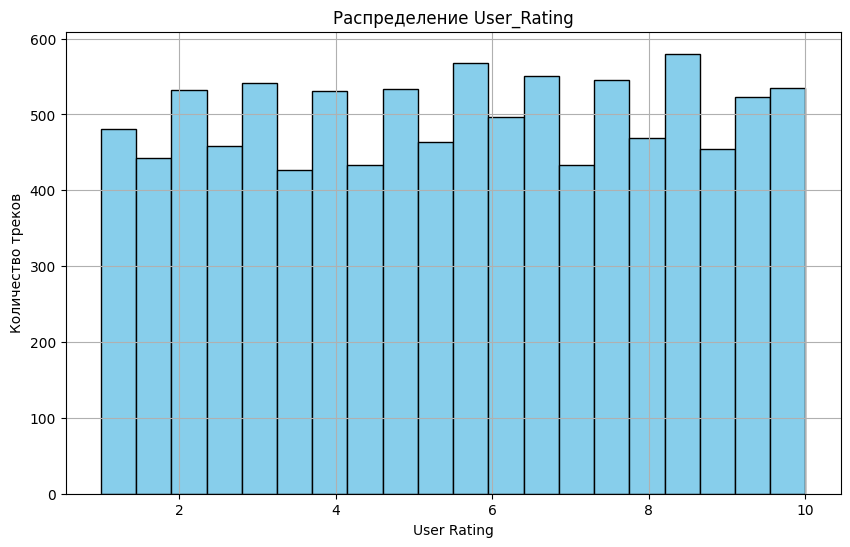

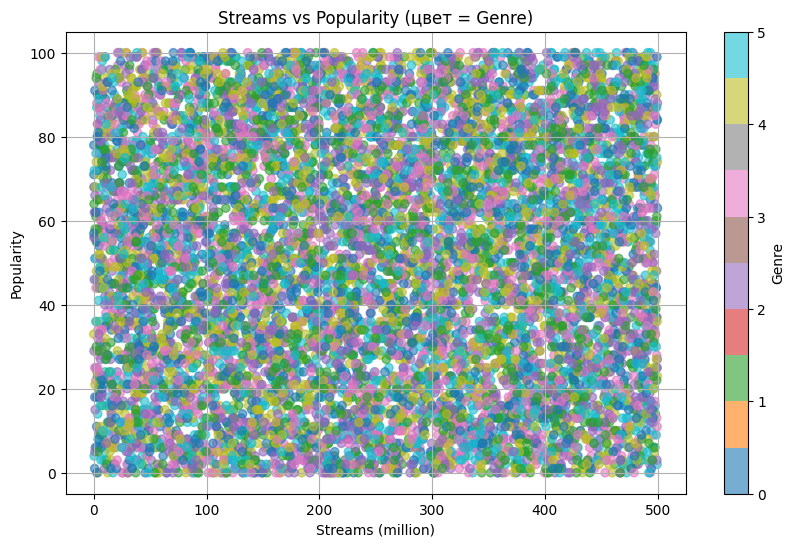

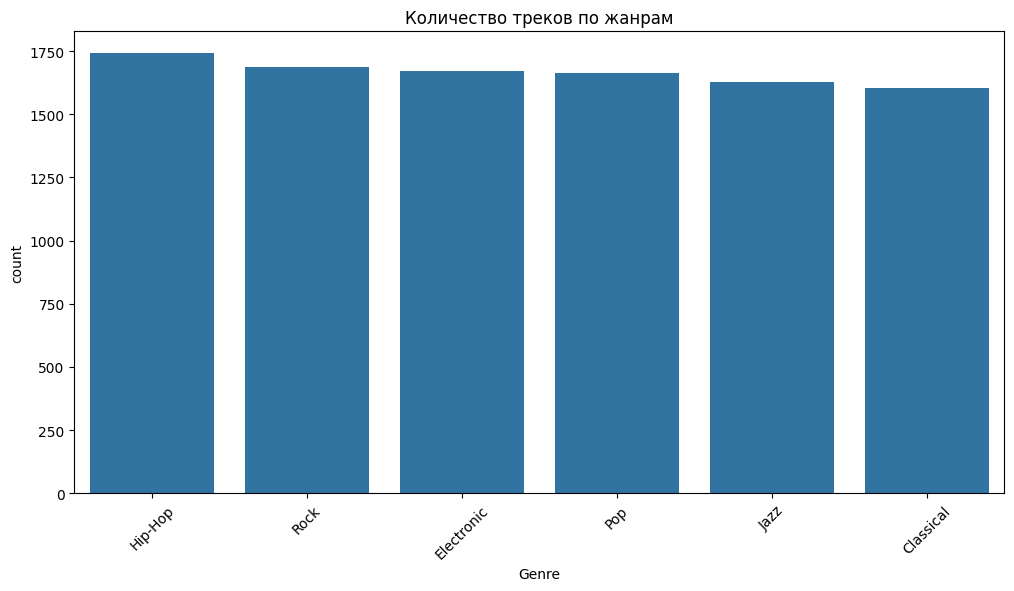

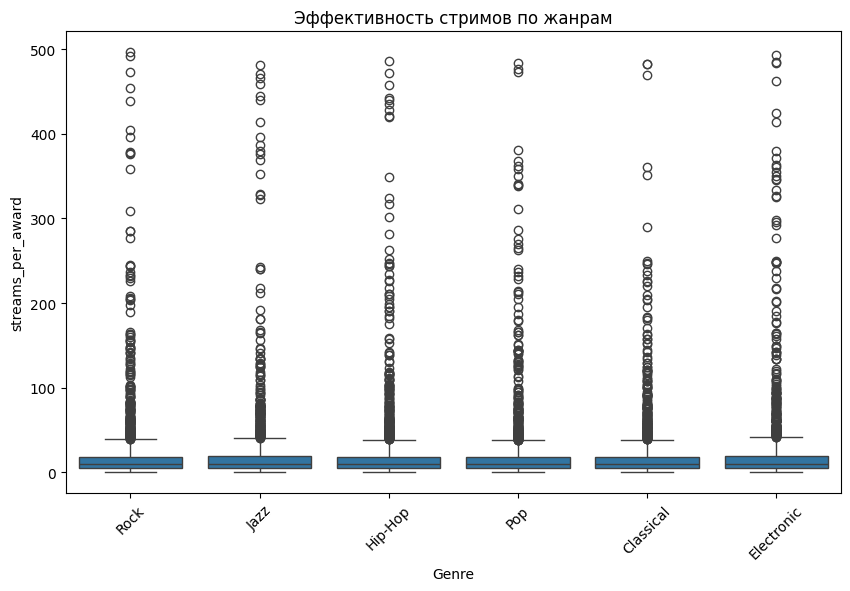

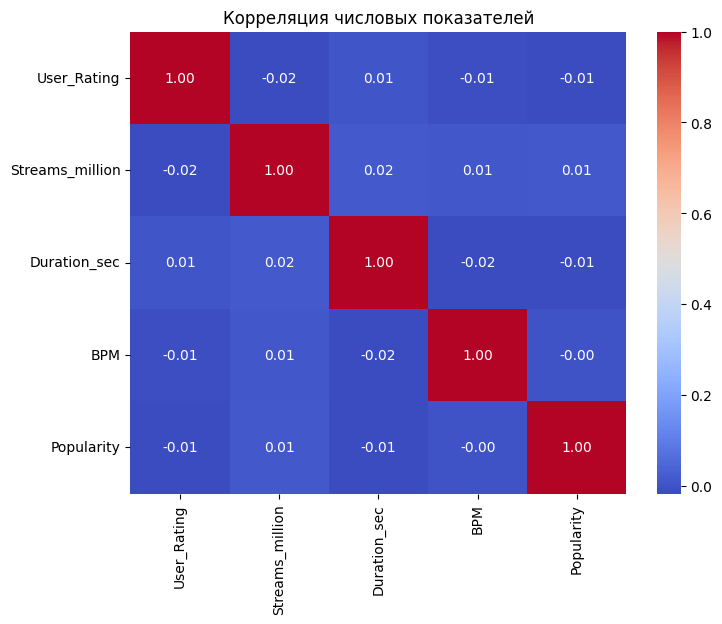


🎉 ВСЕ ЗАДАЧИ ВЫПОЛНЕНЫ!
Сохранены файлы:
   • student2_music_analysis.xlsx
   • student2_rating_pivot.csv
   • student2_efficiency_pivot.csv
   • 4 графика PNG


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====================== НАЧАЛО ======================
# Предполагаем, что датафрейм уже загружен и называется df
# Если у тебя другое название — замени df на своё (например music_df)

print("✅ Датафрейм загружен. Размер:", df.shape)
print(df.columns.tolist())  # чтобы проверить колонки

# ====================== ЗАДАЧА 1 ======================
# 1. NumPy массив из указанных колонок
numeric_cols = ['Year', 'Duration_sec', 'BPM', 'Energy', 'Danceability',
                'Popularity', 'Streams_million', 'Awards_won',
                'Awards_nominated', 'User_Rating']

numeric_data = df[numeric_cols].to_numpy()

print("\n=== Задача 1 ===")
print("Форма массива:", numeric_data.shape)
print("Первые 5 строк:\n", numeric_data[:5])

# ====================== ЗАДАЧА 2 ======================
# 2. Статистика
streams_mean = df['Streams_million'].mean()
streams_median = df['Streams_million'].median()
streams_std = df['Streams_million'].std()

rating_mean = df['User_Rating'].mean()
rating_median = df['User_Rating'].median()
rating_std = df['User_Rating'].std()

pop_mean = df['Popularity'].mean()
pop_median = df['Popularity'].median()
pop_std = df['Popularity'].std()

print("\n=== Задача 2 ===")
print(f"Streams_million: mean={streams_mean:.1f}, median={streams_median:.1f}, std={streams_std:.1f}")
print(f"User_Rating:     mean={rating_mean:.1f}, median={rating_median:.1f}, std={rating_std:.1f}")
print(f"Popularity:      mean={pop_mean:.1f}, median={pop_median:.1f}, std={pop_std:.1f}")

# ====================== ЗАДАЧА 3 ======================
# 3. Фильтрация через NumPy
condition = (df['Streams_million'] > 200) & (df['User_Rating'] >= 8)
indices = np.where(condition)[0]

print("\n=== Задача 3 ===")
print(f"Найдено треков с Streams_million > 200 и User_Rating >= 8: {len(indices)}")

top_tracks = df.loc[indices[:10], ['Title', 'Artist', 'Streams_million', 'User_Rating']]
print(top_tracks)

# ====================== ЗАДАЧА 4 ======================
# 4. Dict: жанр → количество explicit-треков
explicit_by_genre = df[df['Explicit'] == 1].groupby('Genre').size().to_dict()

print("\n=== Задача 4 ===")
print("Топ-3 жанра по explicit-трекам:")
top3_explicit = dict(sorted(explicit_by_genre.items(), key=lambda x: x[1], reverse=True)[:3])
for genre, count in top3_explicit.items():
    print(f"{genre}: {count} треков")

# ====================== ЗАДАЧА 5 ======================
# 5. Set уникальных комбинаций Artist + Album
unique_combos = set(zip(df['Artist'], df['Album']))
print("\n=== Задача 5 ===")
print(f"Уникальных комбинаций Artist + Album: {len(unique_combos)}")

# ====================== ЗАДАЧА 6 ======================
# 6. Lambda + генератор
df['streams_per_award'] = df.apply(
    lambda row: row['Streams_million'] / (row['Awards_won'] + 1), axis=1
)

high_efficiency = (
    (title, artist, streams, spa)
    for title, artist, streams, spa in zip(
        df['Title'], df['Artist'], df['Streams_million'], df['streams_per_award']
    )
    if spa >= 50
)

print("\n=== Задача 6 ===")
print("Первые 10 треков с высокой эффективностью стримов:")
for i, (title, artist, streams, spa) in enumerate(high_efficiency):
    print(f"{i+1}. {title} — {artist} | {streams}M стримов | efficiency = {spa:.1f}")
    if i == 9:
        break

# ====================== ЗАДАЧА 7 ======================
# 7. Сводные таблицы
rating_pivot = df.pivot_table(
    index='Genre',
    columns='Year',
    values='User_Rating',
    aggfunc='mean'
)

efficiency_pivot = df.pivot_table(
    index='Genre',
    columns='Year',
    values='streams_per_award',
    aggfunc='mean'
)

rating_pivot.to_csv('student2_rating_pivot.csv')
efficiency_pivot.to_csv('student2_efficiency_pivot.csv')

print("\n=== Задача 7 ===")
print("Сводные таблицы сохранены:")
print("   → student2_rating_pivot.csv")
print("   → student2_efficiency_pivot.csv")

# ====================== ЗАДАЧА 8 ======================
# 8. Сохранение и чтение Excel
df.to_excel('student2_music_analysis.xlsx', index=False)

# Проверка
df_check = pd.read_excel('student2_music_analysis.xlsx')
print("\n=== Задача 8 ===")
print(f"Excel успешно сохранён и прочитан обратно. Строки совпадают: {len(df) == len(df_check)}")

# ====================== ЗАДАЧА 9 ======================
# 9. Matplotlib
plt.figure(figsize=(10, 6))
plt.hist(df['User_Rating'], bins=20, color='skyblue', edgecolor='black')
plt.title('Распределение User_Rating')
plt.xlabel('User Rating')
plt.ylabel('Количество треков')
plt.grid(True)
plt.savefig('user_rating_histogram.png')
plt.show()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Streams_million'], df['Popularity'],
                     c=df['Genre'].astype('category').cat.codes,
                     cmap='tab10', alpha=0.6)
plt.title('Streams vs Popularity (цвет = Genre)')
plt.xlabel('Streams (million)')
plt.ylabel('Popularity')
plt.grid(True)
plt.colorbar(scatter, label='Genre')
plt.savefig('streams_vs_popularity.png')
plt.show()

# ====================== ЗАДАЧА 10 ======================
# 10. Seaborn
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Genre', order=df['Genre'].value_counts().index)
plt.title('Количество треков по жанрам')
plt.xticks(rotation=45)
plt.savefig('genre_countplot.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Genre', y='streams_per_award')
plt.title('Эффективность стримов по жанрам')
plt.xticks(rotation=45)
plt.savefig('streams_per_award_boxplot.png')
plt.show()

# Heatmap корреляции
numeric_for_corr = ['User_Rating', 'Streams_million', 'Duration_sec', 'BPM', 'Popularity']
corr_matrix = df[numeric_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых показателей')
plt.savefig('correlation_heatmap.png')
plt.show()

print("\n🎉 ВСЕ ЗАДАЧИ ВЫПОЛНЕНЫ!")
print("Сохранены файлы:")
print("   • student2_music_analysis.xlsx")
print("   • student2_rating_pivot.csv")
print("   • student2_efficiency_pivot.csv")
print("   • 4 графика PNG")